# Figure: Tissue-specific pathway retention (engine-native)

This notebook regenerates the tissue-specific pathway-retention heatmap directly
from `ExposoGraph.engine.GraphEngine`, using the domain-specific getters added to
the engine (`get_tissues`, `get_carcinogen_groups`, `carcinogens_by_group`) instead
of a hand-maintained tissue list / carcinogen-class mapping. It's a tighter,
graph-native companion to `Figure-2-tissue-specific-pathway-retention.ipynb`,
**not** a drop-in replacement that reproduces identical numbers -- see the
"How this compares to Figure 2" section below for the methodological differences
and why they change the resulting values.

In [1]:
from __future__ import annotations
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
from ExposoGraph.engine import GraphEngine

## 1. Instantiate the knowledge graph via `engine.py`

Uses `GraphEngine.load_reference_graph()` directly -- the same canonical loading
path (bundled `graph-data.json` + tissue expression + interaction parameters)
that the rest of the package relies on.

In [2]:
engine = GraphEngine()
load_warnings = engine.load_reference_graph()
if load_warnings:
    print(f"\n{len(load_warnings)} load warning(s):")
    for warning in load_warnings:
        print(f"  - {warning}")


1 load warning(s):
  - No tissue expression data for enzyme: GSTT1


In [3]:
TISSUES = engine.get_tissues()
print(f"{len(TISSUES)} tissues")
CARCINOGEN_CATEGORIES = engine.get_carcinogen_groups()
print(f"{len(CARCINOGEN_CATEGORIES)} carcinogen categories")

10 tissues
21 carcinogen categories


## 4. Retention ratio

For each (carcinogen category, tissue) cell:

- **Denominator** -- the number of graph edges whose `carcinogen` field names a
  `Carcinogen` node in that category (see point 4 in the comparison above),
  further restricted to edges where at least one of the two adjacent nodes has
  a non-null `tissue_weights` dict (i.e. the edge has some tissue-expression
  context to evaluate at all).
- **Numerator** -- the subset of those edges where at least one endpoint
  (source or target) is an `Enzyme` node with
  `tissue_weights[tissue] >= TISSUE_WEIGHT_THRESHOLD`.
- **Cell value** = `100 * numerator / denominator`, or `NaN` (shown as `n/a`) if
  the category has zero qualifying edges.

`TISSUE_WEIGHT_THRESHOLD` is on the engine's normalized 0-1 `tissue_weights`
scale -- see comparison point 2 above before treating this as equivalent to the
old notebook's raw-nTPM `0.25` cutoff.

In [4]:
TISSUE_WEIGHT_THRESHOLD = 0.25

node_data = dict(engine.G.nodes(data=True))
edges = [(u, v, data) for u, v, data in engine.G.edges(data=True)]

category_carcinogen_ids = {
    category: {node["id"] for node in engine.carcinogens_by_group(category)}
    for category in CARCINOGEN_CATEGORIES
}


def enzyme_meets_threshold(node_id: str, tissue: str, threshold: float) -> bool:
    data = node_data.get(node_id)
    if data is None or data.get("type") != "Enzyme":
        return False
    weights = data.get("tissue_weights")
    if not weights:
        return False
    return weights.get(tissue, float("-inf")) >= threshold


def has_tissue_weights(node_id: str) -> bool:
    data = node_data.get(node_id)
    if data is None:
        return False
    return bool(data.get("tissue_weights"))


rows: list[list[float]] = []
denominators: dict[str, int] = {}

for category in CARCINOGEN_CATEGORIES:
    carcinogen_ids = category_carcinogen_ids[category]
    category_edges = [
        (u, v, data)
        for u, v, data in edges
        if data.get("carcinogen") in carcinogen_ids
        and (has_tissue_weights(u) or has_tissue_weights(v))
    ]
    denominators[category] = len(category_edges)

    row: list[float] = []
    for tissue in TISSUES:
        if not category_edges:
            row.append(np.nan)
            continue
        numerator = sum(
            1
            for u, v, _ in category_edges
            if enzyme_meets_threshold(u, tissue, TISSUE_WEIGHT_THRESHOLD)
            or enzyme_meets_threshold(v, tissue, TISSUE_WEIGHT_THRESHOLD)
        )
        row.append(100.0 * numerator / len(category_edges))
    rows.append(row)

retention = pd.DataFrame(rows, index=CARCINOGEN_CATEGORIES, columns=TISSUES)


## 5. Heatmap

Seaborn heatmap with a blue/red diverging colormap (`RdBu_r`: low retention ->
blue, high retention -> red), centered at 50%. Categories with no graph edges at
all are masked and annotated `n/a`. Not saved to disk -- rendered inline only.

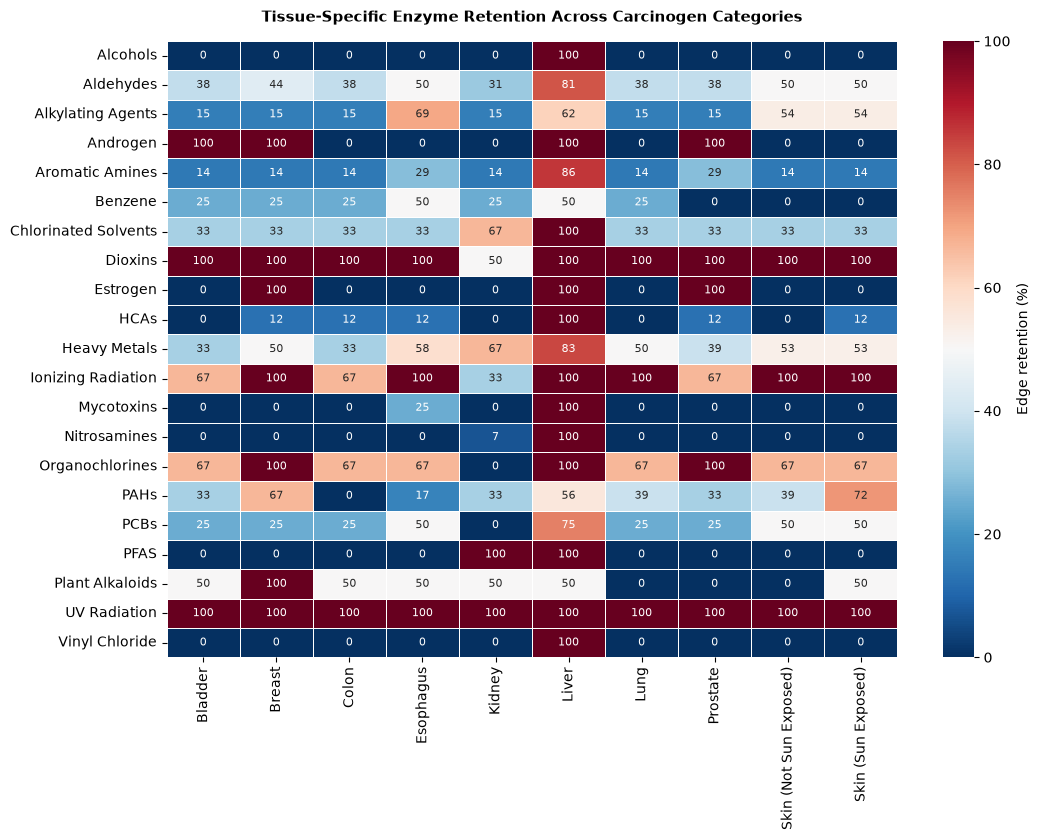

In [5]:
fig, ax = plt.subplots(figsize=(11, 8.5))

mask = retention.isna()
sns.heatmap(
    retention,
    ax=ax,
    cmap="RdBu_r",
    vmin=0,
    vmax=100,
    center=50,
    mask=mask,
    annot=True,
    fmt=".0f",
    annot_kws={"fontsize": 8},
    linewidths=0.5,
    linecolor="white",
    square=False,
    cbar_kws={"label": "Edge retention (%)"},
)
ax.set_facecolor("#e8e8e8")

for row_idx, category in enumerate(CARCINOGEN_CATEGORIES):
    if denominators[category] == 0:
        for col_idx in range(len(TISSUES)):
            ax.text(
                col_idx,
                row_idx,
                "n/a",
                ha="center",
                va="center",
                fontsize=8,
                color="#666666",
            )

ax.set_title(
    "Tissue-Specific Enzyme Retention Across Carcinogen Categories",
    fontsize=11,
    weight="bold",
    pad=14,
)
plt.setp(ax.get_xticklabels(), rotation=90) 
fig.tight_layout()
plt.show()

In [6]:
retention.mean(axis=1)

Alcohols                 10.000000
Aldehydes                45.625000
Alkylating Agents        33.076923
Androgen                 40.000000
Aromatic Amines          24.285714
Benzene                  22.500000
Chlorinated Solvents     43.333333
Dioxins                  95.000000
Estrogen                 30.000000
HCAs                     16.250000
Heavy Metals             51.944444
Ionizing Radiation       83.333333
Mycotoxins               12.500000
Nitrosamines             10.666667
Organochlorines          70.000000
PAHs                     38.888889
PCBs                     35.000000
PFAS                     20.000000
Plant Alkaloids          40.000000
UV Radiation            100.000000
Vinyl Chloride           10.000000
dtype: float64